In [3]:
import numpy as np
import matplotlib.pyplot as plt

Sigmoid Function

In [4]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

Model hypothesis

In [21]:
def predict(X, w):
    m, b = w   # unpack parameters
    z = m * X + b
    return sigmoid(z)

Cost function

In [6]:
def compute_cost(y,y_hat):
    n = len(y)
    epsiolon = 1e-10
    return -1/n * (y*np.log(y_hat + epsiolon) + (1-y)*np.log(1-y_hat + epsiolon)).sum()

Partial derivative

In [7]:
def compute_gradient(X, y, y_hat):
    n = len(y)
    error = y_hat
    dw = 1/n * (X*error).sum()
    db = 1/n * error.sum()
    return dw, db

update parameters

In [8]:
def update_paramters(m,b,dm,db,aplha):
    m = m - aplha*dm
    b = b - aplha*db
    return m, b

Initialize paramters

In [10]:
def initialize_parameters():
    m = 0
    b = 0
    return m, b

model training

In [11]:
def train(x,y,alpha=0.1,iterations=1000):
    m, b = initialize_parameters()
    loss_history = []
    for i in range(iterations):
        y_hat = predict(x, (m,b))
        loss = compute_cost(y,y_hat)
        loss_history.append(loss)
        dm, db = compute_gradient(x,y,y_hat)
        m, b = update_paramters(m,b,dm,db,alpha)
        if i%200 == 0:
            print(f"Iteration {i}, Loss: {loss}")   
    return m, b, loss_history
    

dataset Loading 

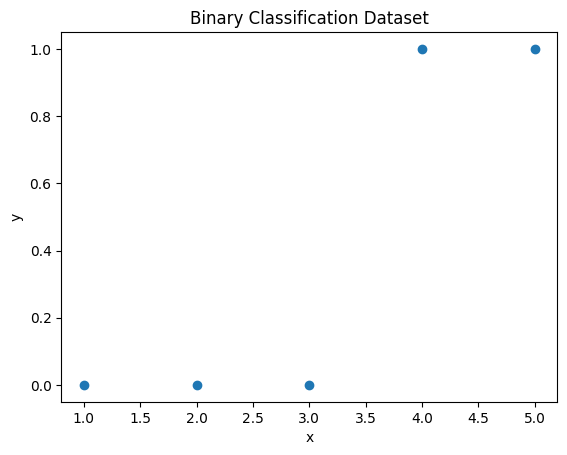

In [17]:
x=np.array([1,2,3,4,5],dtype=float)
y=np.array([0,0,0,1,1],dtype=float)
plt.scatter(x,y)
plt.xlabel("x")
plt.ylabel("y") 
plt.title("Binary Classification Dataset")
plt.show()

train model

In [22]:
m,b,loss_history = train(x,y,alpha=0.1,iterations=1000)
print("\nfinal parameters")

Iteration 0, Loss: 0.6931471803599454
Iteration 200, Loss: 3.4260361898710943
Iteration 400, Loss: 4.0500251828385245
Iteration 600, Loss: 4.43368572051701
Iteration 800, Loss: 4.712761990257637

final parameters


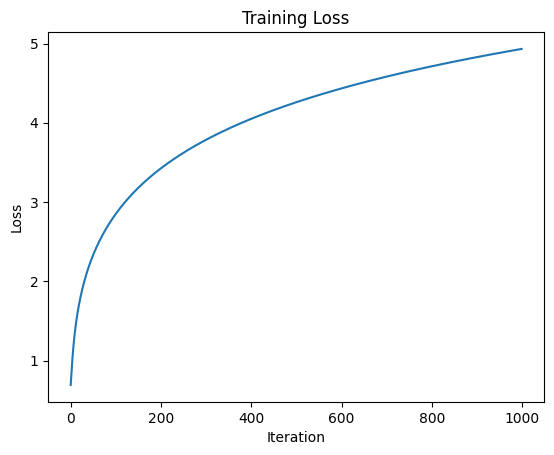

In [24]:
plt.figure()
plt.plot(loss_history)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

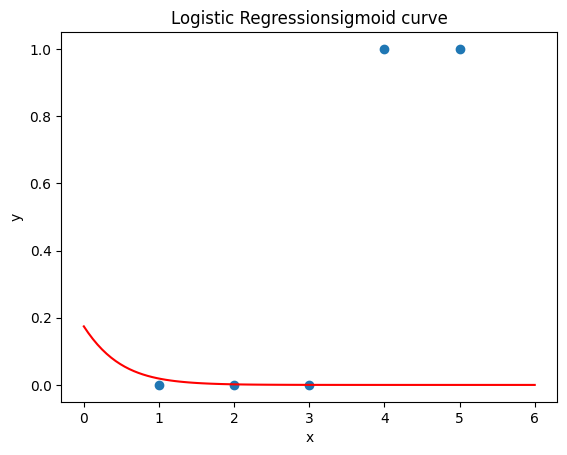

In [25]:
x_curve = np.linspace(0,6,100)
y_curve = predict(x_curve, (m,b))
plt.scatter(x,y)
plt.plot(x_curve, y_curve, color='red') 
plt.xlabel("x")
plt.ylabel("y")     
plt.title("Logistic Regressionsigmoid curve")
plt.show()